# SFT Results Visualization

In [133]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
# ============================================
# Directory Configuration
# ============================================
# Configure these paths for your cluster:
# - SCRATCH_DIR: where large files (data, outputs) are stored

SCRATCH_DIR = "/work/hdd/bfwm/phu1/Project"

print(f"SCRATCH_DIR: {SCRATCH_DIR}")

# ============================================
# Experiment Configuration
# ============================================
model = 'Llama-3.2-1B'
train_dataset = 'alpaca'  # Options: alpaca, tulu3, less
task = 'samsum'          # Options: samsum, tydiqa, mmlu_sociology, bbh_navigate
subject = ''           # Only needed for mmlu/bbh tasks
out_dir = f"{SCRATCH_DIR}/Gradient-Streaming/SFT"
lr_config_path = "./train/lr/config.json"  # Path to LR configuration

# Configuration used for experiments
# See SFT/README.md for recommended parameters per dataset
# Note: seed is auto-discovered from available experiment directories
default_config = {
    'batch_size': 8,
    'percentage': 0.4,   # alpaca: 0.4, tulu3: 0.01, less: 0.05
    'n_val': 32,
    # Learning rates are now loaded from config.json per experiment
    # Fallback values used only if config lookup fails
    'lr_full_fallback': '5e-05',
    'lr_lora_fallback': '2e-04',
}

# Load LR configuration
lr_config = {}
if Path(lr_config_path).exists():
    with open(lr_config_path, 'r') as f:
        lr_config = json.load(f)
    print(f"Loaded LR config from {lr_config_path}")
else:
    print(f"Warning: LR config not found at {lr_config_path}, using fallback LRs")

# ============================================
# Method Definitions
# ============================================
# Format: (selection, compression, training_type, use_second_order)
methods = {
    # Baselines (NA-NA): no selection, no compression
    'NA-NA-Full': ('NA', 'NA', 'Full', False),
    'NA-NA-LoRA': ('NA', 'NA', 'LoRA', False),

    # Streaming without compression (per-layer selection)
    'Streaming-NA-Full': ('Streaming', 'NA', 'Full', True),
    'Streaming-NA-LoRA': ('Streaming', 'NA', 'LoRA', True),

    # GREATS without compression (global selection)
    'GREATS-NA-Full': ('GREATS', 'NA', 'Full', True),
    'GREATS-NA-LoRA': ('GREATS', 'NA', 'LoRA', True),

    # Streaming with compression (MeSO optimizer)
    'Streaming-LoGra-Full': ('Streaming', 'LoGra', 'Full', True),

    # GREATS with compression (MeSO optimizer)
    'GREATS-LoGra-Full': ('GREATS', 'LoGra', 'Full', True),
}

print(f"\nDefined {len(methods)} methods:")
for name in methods:
    print(f"  - {name}")

In [ ]:
model = 'Llama-3.2-1B'
train_dataset = 'alpaca'  # Options: alpaca, tulu3, less
task = 'samsum'          # Options: samsum, tydiqa, mmlu_sociology, bbh_navigate
subject = ''           # Only needed for mmlu/bbh tasks
out_dir = "/scratch/pbb/Project/Gradient-Streaming/SFT"
lr_config_path = "./train/lr/config.json"  # Path to LR configuration

# Configuration used for experiments
# See SFT/README.md for recommended parameters per dataset
# Note: seed is auto-discovered from available experiment directories
default_config = {
    'batch_size': 8,
    'percentage': 0.4,   # alpaca: 0.4, tulu3: 0.01, less: 0.05
    'n_val': 32,
    # Learning rates are now loaded from config.json per experiment
    # Fallback values used only if config lookup fails
    'lr_full_fallback': '5e-05',
    'lr_lora_fallback': '2e-04',
}

# Load LR configuration
lr_config = {}
if Path(lr_config_path).exists():
    with open(lr_config_path, 'r') as f:
        lr_config = json.load(f)
    print(f"Loaded LR config from {lr_config_path}")
else:
    print(f"Warning: LR config not found at {lr_config_path}, using fallback LRs")

# ============================================
# Method Definitions
# ============================================
# Format: (selection, compression, training_type, use_second_order)
methods = {
    # Baselines (NA-NA): no selection, no compression
    'NA-NA-Full': ('NA', 'NA', 'Full', False),
    'NA-NA-LoRA': ('NA', 'NA', 'LoRA', False),

    # Streaming without compression (per-layer selection)
    'Streaming-NA-Full': ('Streaming', 'NA', 'Full', True),
    'Streaming-NA-LoRA': ('Streaming', 'NA', 'LoRA', True),

    # GREATS without compression (global selection)
    'GREATS-NA-Full': ('GREATS', 'NA', 'Full', True),
    'GREATS-NA-LoRA': ('GREATS', 'NA', 'LoRA', True),

    # Streaming with compression (MeSO optimizer)
    'Streaming-LoGra-Full': ('Streaming', 'LoGra', 'Full', True),

    # GREATS with compression (MeSO optimizer)
    'GREATS-LoGra-Full': ('GREATS', 'LoGra', 'Full', True),
}

print(f"\nDefined {len(methods)} methods:")
for name in methods:
    print(f"  - {name}")

Loaded LR config from /home/pbb/Project/Gradient-Streaming/SFT/train/lr/config.json

Defined 8 methods:
  - NA-NA-Full
  - NA-NA-LoRA
  - Streaming-NA-Full
  - Streaming-NA-LoRA
  - GREATS-NA-Full
  - GREATS-NA-LoRA
  - Streaming-LoGra-Full
  - GREATS-LoGra-Full


## Load Results

In [135]:
def load_results(result_path):
    """Load evaluation results from JSON file."""
    with open(result_path, 'r') as f:
        data = json.load(f)

    steps = [item['step'] for item in data]
    val_perplexity = [item['val_perplexity'] for item in data]
    eval_perplexity = [item['eval_perplexity'] for item in data]
    wall_time = [item.get('wall_time', None) for item in data]

    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_perplexity),
        'eval_perplexity': np.array(eval_perplexity),
        'wall_time': np.array(wall_time) if all(t is not None for t in wall_time) else None,
    }


def build_config_key(train_dataset, task, subject=None):
    """
    Build config key for LR lookup. Includes subject for mmlu/bbh tasks.

    Examples:
        - alpaca + samsum -> 'alpaca_samsum'
        - less + mmlu + world_religions -> 'less_mmlu_world_religions'
    """
    if task in ['mmlu', 'bbh'] and subject:
        return f"{train_dataset}_{task}_{subject}"
    else:
        return f"{train_dataset}_{task}"


def lookup_lr(method_name, config_key, training_type):
    """
    Look up learning rate from lr_config.json.

    Args:
        method_name: e.g., 'NA-NA-Full', 'Streaming-LoGra-Full'
        config_key: e.g., 'alpaca_samsum', 'less_mmlu_world_religions'
        training_type: 'Full' or 'LoRA'

    Returns:
        LR as string (e.g., '5e-06', '0.0001')
    """
    # Try to look up from config
    if lr_config and config_key in lr_config:
        entry = lr_config[config_key].get(method_name, {})
        lr_val = entry.get('lr')
        if lr_val is not None:
            # Format LR consistently: scientific notation for small values
            if lr_val < 0.001:
                return f'{lr_val:.0e}'
            else:
                return f'{lr_val}'

    # Fallback to defaults
    if training_type == 'LoRA':
        return default_config['lr_lora_fallback']
    else:
        return default_config['lr_full_fallback']


def build_experiment_dir_pattern(train_dataset, task, method_name, config=None, subject=None):
    """
    Build a glob pattern to find all seeds for an experiment.
    Returns (pattern, base_dir_prefix) where the pattern matches seed variations.
    """
    if method_name not in methods:
        return None, None

    selection, compression, training_type, use_second_order = methods[method_name]
    cfg = config or default_config
    batch_size = cfg['batch_size']
    percentage = cfg['percentage']
    n_val = cfg['n_val']

    # Build config key for LR lookup
    config_key = build_config_key(train_dataset, task, subject)
    lr = lookup_lr(method_name, config_key, training_type)

    # Build method string (selection-compression, no -2nd suffix)
    method_str = f"{selection}-{compression}"

    # Build task string
    if task in ['mmlu', 'bbh'] and subject:
        task_str = f"{task}_{subject}"
    else:
        task_str = task

    # Directory pattern with wildcard for seed
    dir_pattern = f"{train_dataset}_{task_str}-{model}-{method_str}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s*"

    return f"{out_dir}/{dir_pattern}", f"{train_dataset}_{task_str}-{model}-{method_str}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s"


def discover_seeds(train_dataset, task, method_name, config=None, subject=None):
    """
    Discover all available seeds for a given experiment setup.
    Returns a sorted list of seed values found.
    """
    pattern, base_prefix = build_experiment_dir_pattern(train_dataset, task, method_name, config, subject)
    if pattern is None:
        return []

    # Find matching directories
    matching_dirs = glob(pattern)

    # Extract seeds from directory names
    seeds = []
    seed_pattern = re.compile(r'-s(\d+)$')
    for dir_path in matching_dirs:
        dir_name = Path(dir_path).name
        match = seed_pattern.search(dir_name)
        if match:
            seeds.append(int(match.group(1)))

    return [42]
    return sorted(seeds)


def build_experiment_path(train_dataset, task, method_name, seed, config=None, subject=None):
    """
    Build the experiment directory path for a specific seed.
    """
    if method_name not in methods:
        return None

    selection, compression, training_type, use_second_order = methods[method_name]
    cfg = config or default_config
    batch_size = cfg['batch_size']
    percentage = cfg['percentage']
    n_val = cfg['n_val']

    config_key = build_config_key(train_dataset, task, subject)
    lr = lookup_lr(method_name, config_key, training_type)

    # Build method string (selection-compression, no -2nd suffix)
    method_str = f"{selection}-{compression}"

    if task in ['mmlu', 'bbh'] and subject:
        task_str = f"{task}_{subject}"
    else:
        task_str = task

    dir_name = f"{train_dataset}_{task_str}-{model}-{method_str}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s{seed}"

    return f"{out_dir}/{dir_name}/evaluation_results.json"


def load_multi_seed_results(train_dataset, task, method_name, config=None, subject=None):
    """
    Load and aggregate results across all available seeds for a method.

    Returns a dict with:
    - steps: common steps across all seeds
    - val_perplexity_mean, val_perplexity_std
    - eval_perplexity_mean, eval_perplexity_std
    - wall_time_mean, wall_time_std (if available)
    - n_seeds: number of seeds found
    - seeds: list of seeds used
    - points_per_seed: dict mapping seed -> number of points
    """
    seeds = discover_seeds(train_dataset, task, method_name, config, subject)
    if not seeds:
        return None

    all_results = []
    valid_seeds = []

    for seed in seeds:
        path = build_experiment_path(train_dataset, task, method_name, seed, config, subject)
        if path and Path(path).exists():
            result = load_results(path)
            all_results.append(result)
            valid_seeds.append(seed)

    if not all_results:
        return None

    # Track points per seed for informative logging
    points_per_seed = {seed: len(r['steps']) for seed, r in zip(valid_seeds, all_results)}

    # Find common steps across all seeds (use the minimum length)
    min_len = min(len(r['steps']) for r in all_results)

    # Stack arrays for aggregation (truncate to common length)
    steps = all_results[0]['steps'][:min_len]
    val_perplexity = np.stack([r['val_perplexity'][:min_len] for r in all_results])
    eval_perplexity = np.stack([r['eval_perplexity'][:min_len] for r in all_results])

    # Handle wall time
    wall_times = [r['wall_time'] for r in all_results if r['wall_time'] is not None]
    if len(wall_times) == len(all_results):
        wall_time_stack = np.stack([wt[:min_len] for wt in wall_times])
        wall_time_mean = np.mean(wall_time_stack, axis=0)
        wall_time_std = np.std(wall_time_stack, axis=0)
    else:
        wall_time_mean = None
        wall_time_std = None

    return {
        'steps': steps,
        'val_perplexity_mean': np.mean(val_perplexity, axis=0),
        'val_perplexity_std': np.std(val_perplexity, axis=0),
        'eval_perplexity_mean': np.mean(eval_perplexity, axis=0),
        'eval_perplexity_std': np.std(eval_perplexity, axis=0),
        'wall_time_mean': wall_time_mean,
        'wall_time_std': wall_time_std,
        'n_seeds': len(valid_seeds),
        'seeds': valid_seeds,
        'points_per_seed': points_per_seed,
    }


# Load all results with multi-seed aggregation
results = {}
print(f"Loading results for: {train_dataset} -> {task}" + (f" ({subject})" if subject else ""))
print(f"Config key: {build_config_key(train_dataset, task, subject)}")
print("=" * 60)

for method_name in methods.keys():
    data = load_multi_seed_results(train_dataset, task, method_name, default_config, subject)
    if data:
        results[method_name] = data
        # Print per-seed point counts
        points_str = ", ".join(f"s{seed}:{pts}" for seed, pts in data['points_per_seed'].items())
        print(f"+ {method_name}: {data['n_seeds']} seeds")
        print(f"    Points per seed: {points_str} (using {len(data['steps'])} common)")
    else:
        # Try to discover what's available
        seeds = discover_seeds(train_dataset, task, method_name, default_config, subject)
        if seeds:
            print(f"- {method_name}: Seeds found {seeds} but no valid results")
        else:
            print(f"- {method_name}: Not found")

print("=" * 60)
print(f"Loaded {len(results)}/{len(methods)} experiments")

Loading results for: alpaca -> samsum
Config key: alpaca_samsum
+ NA-NA-Full: 1 seeds
    Points per seed: s42:55 (using 55 common)
+ NA-NA-LoRA: 1 seeds
    Points per seed: s42:54 (using 54 common)
+ Streaming-NA-Full: 1 seeds
    Points per seed: s42:55 (using 55 common)
+ Streaming-NA-LoRA: 1 seeds
    Points per seed: s42:55 (using 55 common)
+ GREATS-NA-Full: 1 seeds
    Points per seed: s42:55 (using 55 common)
+ GREATS-NA-LoRA: 1 seeds
    Points per seed: s42:55 (using 55 common)
+ Streaming-LoGra-Full: 1 seeds
    Points per seed: s42:55 (using 55 common)
+ GREATS-LoGra-Full: 1 seeds
    Points per seed: s42:55 (using 55 common)
Loaded 8/8 experiments


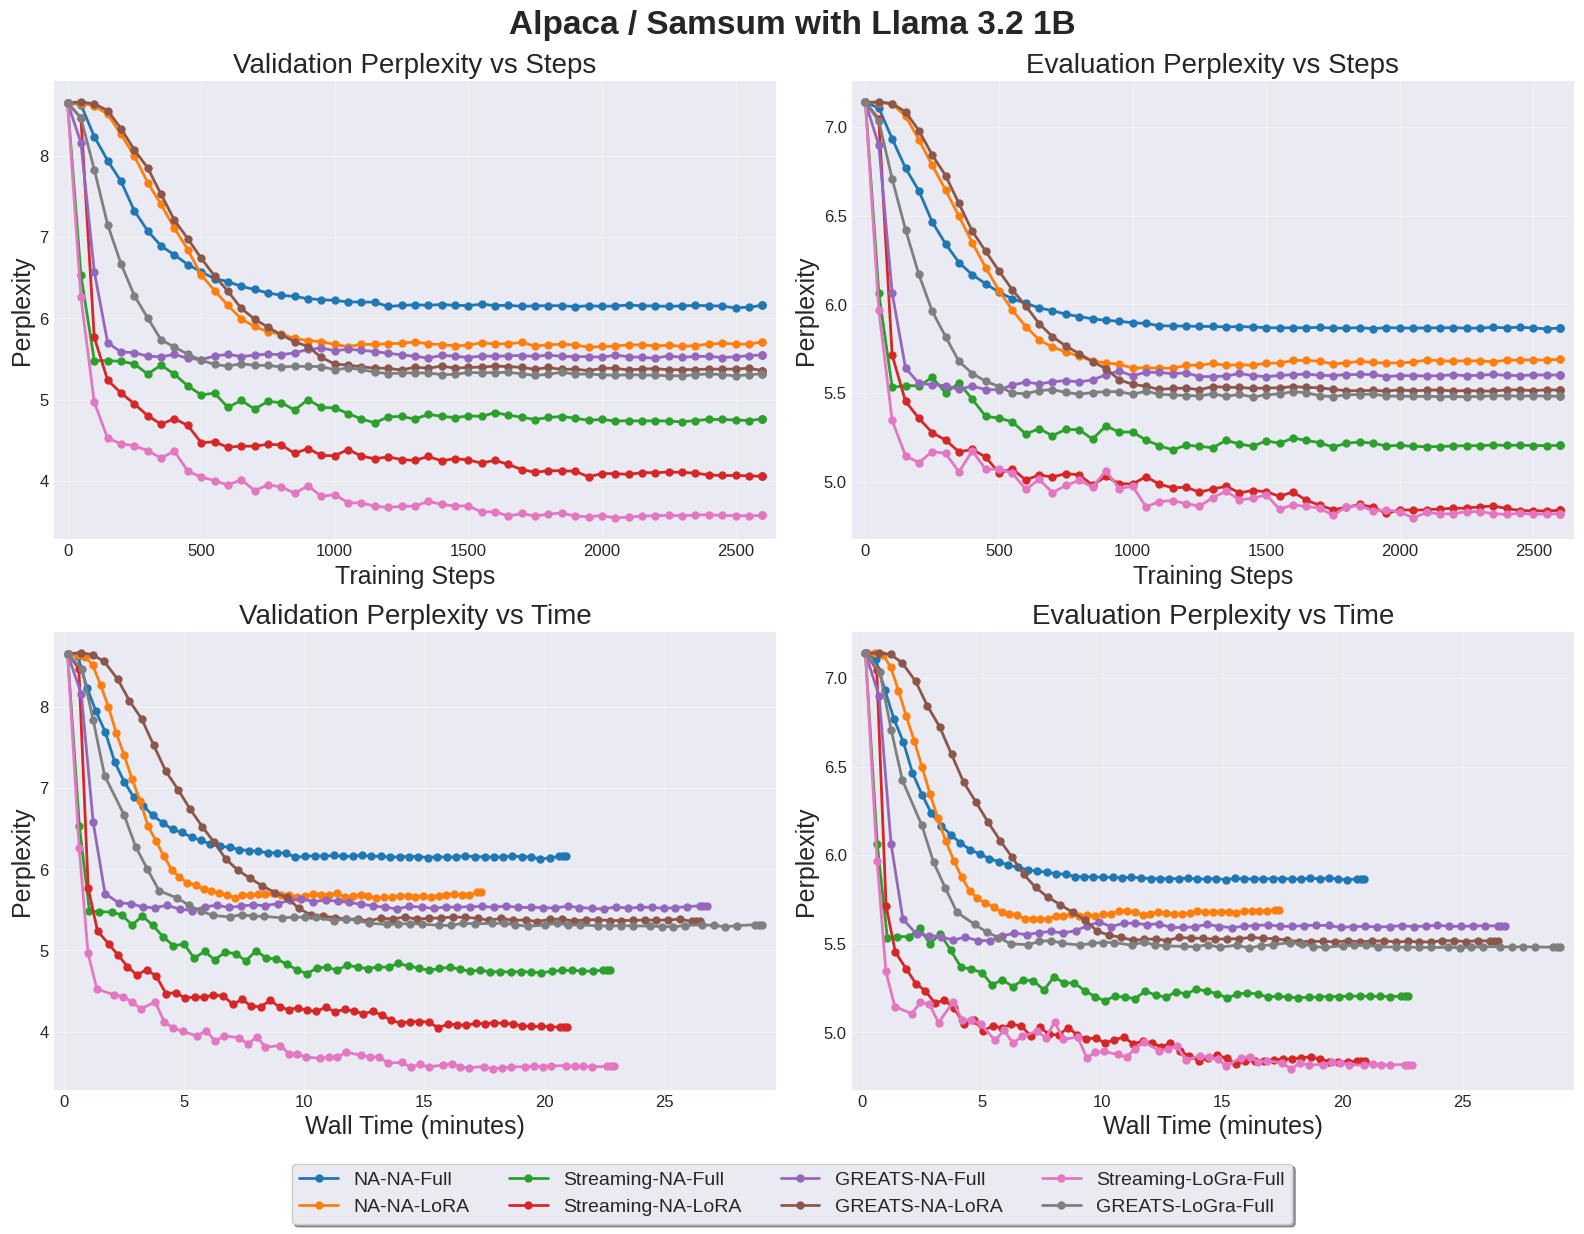

In [136]:
# Unified 2x2 plot: Training Steps (top) vs Wall Time (bottom)
# Left column: Validation Perplexity, Right column: Evaluation Perplexity
# Now with confidence intervals (shaded regions) for multi-seed results

# Check if wall time data is available
has_wall_time = any(data['wall_time_mean'] is not None for data in results.values())

# Build plot title
train_name = train_dataset.replace('_', ' ').title()
task_name = task.upper() if task in ['tydiqa', 'mmlu', 'bbh', 'gsm8k'] else task.replace('_', ' ').title()
if subject:
    task_name = f"{task_name} ({subject.replace('_', ' ').title()})"
model_name = model.replace('_', ' ').replace('-', ' ').title()

# Count total seeds across methods
total_seeds = set()
for data in results.values():
    total_seeds.update(data['seeds'])
# seeds_str = f" ({len(total_seeds)} seeds)" if total_seeds else ""
plot_title = f"{train_name} / {task_name} with {model_name}"

# Create figure: 2x2 if wall time available, 1x2 otherwise
n_rows = 2 if has_wall_time else 1
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 6 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

fig.suptitle(plot_title, fontsize=24, fontweight='bold', y=0.98)

# Store handles and labels for unified legend
legend_handles = []
legend_labels = []

def plot_perplexity_with_ci(ax, x_data, y_mean, y_std, x_label, title, method_names, data_dict, collect_legend=False):
    """Helper to plot perplexity with confidence intervals (shaded regions)."""
    for name in method_names:
        if name not in data_dict:
            continue
        data = data_dict[name]
        x = x_data(data)
        mean = y_mean(data)
        std = y_std(data)
        if x is None or mean is None:
            continue

        # Plot mean line with dot markers
        line, = ax.plot(x, mean, linewidth=2, marker='o', markersize=5, label=name)
        color = line.get_color()

        # Add shaded confidence interval (±1 std)
        if std is not None and data['n_seeds'] > 1:
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        # Collect handles and labels for legend (only once)
        if collect_legend:
            legend_handles.append(line)
            legend_labels.append(name)

    ax.set_xlabel(x_label, fontsize=18)
    ax.set_ylabel('Perplexity', fontsize=18)
    ax.set_title(title, fontsize=20)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.02)

# Row 1: Perplexity vs Training Steps
plot_perplexity_with_ci(
    axes[0, 0],
    x_data=lambda d: d['steps'],
    y_mean=lambda d: d['val_perplexity_mean'],
    y_std=lambda d: d['val_perplexity_std'],
    x_label='Training Steps',
    title='Validation Perplexity vs Steps',
    method_names=results.keys(),
    data_dict=results,
    collect_legend=True  # Collect legend from first plot
)

plot_perplexity_with_ci(
    axes[0, 1],
    x_data=lambda d: d['steps'],
    y_mean=lambda d: d['eval_perplexity_mean'],
    y_std=lambda d: d['eval_perplexity_std'],
    x_label='Training Steps',
    title='Evaluation Perplexity vs Steps',
    method_names=results.keys(),
    data_dict=results
)

# Row 2: Perplexity vs Wall Time (if available)
if has_wall_time:
    plot_perplexity_with_ci(
        axes[1, 0],
        x_data=lambda d: d['wall_time_mean'] / 60.0 if d['wall_time_mean'] is not None else None,
        y_mean=lambda d: d['val_perplexity_mean'],
        y_std=lambda d: d['val_perplexity_std'],
        x_label='Wall Time (minutes)',
        title='Validation Perplexity vs Time',
        method_names=results.keys(),
        data_dict=results
    )

    plot_perplexity_with_ci(
        axes[1, 1],
        x_data=lambda d: d['wall_time_mean'] / 60.0 if d['wall_time_mean'] is not None else None,
        y_mean=lambda d: d['eval_perplexity_mean'],
        y_std=lambda d: d['eval_perplexity_std'],
        x_label='Wall Time (minutes)',
        title='Evaluation Perplexity vs Time',
        method_names=results.keys(),
        data_dict=results
    )

# Add unified legend at the bottom of the figure
fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=min(len(legend_labels), 4),  # Up to 4 columns
    fontsize=14,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12 if n_rows == 1 else 0.08)  # Make room for legend
plt.show()

## Compare Final Performance

In [137]:
# Print final results with mean ± std across seeds
print(f"\n{'='*100}")
print(f"Final Perplexity Results: {train_dataset} → {task}")
print(f"{'='*100}")
print(f"{'Method':<30} {'Seeds':<8} {'Val Perplexity':<22} {'Eval Perplexity':<22}")
print("-" * 100)

# Sort by eval perplexity mean for easier comparison
sorted_results = sorted(results.items(), key=lambda x: x[1]['eval_perplexity_mean'][-1])

for name, data in sorted_results:
    n_seeds = data['n_seeds']
    final_val_mean = data['val_perplexity_mean'][-1]
    final_val_std = data['val_perplexity_std'][-1]
    final_eval_mean = data['eval_perplexity_mean'][-1]
    final_eval_std = data['eval_perplexity_std'][-1]

    if n_seeds > 1:
        val_str = f"{final_val_mean:.4f} ± {final_val_std:.4f}"
        eval_str = f"{final_eval_mean:.4f} ± {final_eval_std:.4f}"
    else:
        val_str = f"{final_val_mean:.4f}"
        eval_str = f"{final_eval_mean:.4f}"

    print(f"{name:<30} {n_seeds:<8} {val_str:<22} {eval_str:<22}")

print("=" * 100)


Final Perplexity Results: alpaca → samsum
Method                         Seeds    Val Perplexity         Eval Perplexity       
----------------------------------------------------------------------------------------------------
Streaming-LoGra-Full           1        3.5739                 4.8187                
Streaming-NA-LoRA              1        4.0550                 4.8379                
Streaming-NA-Full              1        4.7614                 5.2038                
GREATS-LoGra-Full              1        5.3172                 5.4809                
GREATS-NA-LoRA                 1        5.3575                 5.5155                
GREATS-NA-Full                 1        5.5494                 5.6008                
NA-NA-LoRA                     1        5.7146                 5.6909                
NA-NA-Full                     1        6.1588                 5.8661                


## Task-Specific Evaluation Results

Load and display task-specific metrics:
- **SAMSum**: ROUGE-1, ROUGE-2, ROUGE-L (summarization)
- **TyDiQA**: F1 Score, Exact Match (question answering)
- **MMLU/BBH**: Accuracy (multiple choice)
- **GSM8K/MATH500**: Accuracy (math reasoning)

In [138]:
# Task-specific evaluation metrics configuration
TASK_METRICS = {
    'samsum': {
        'result_file': 'samsum_results.json',
        'metrics': ['rouge1', 'rouge2', 'rougeL'],
        'display_names': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
        'primary_metric': 'rougeL',
        'format': lambda x: f"{x:.3f}" if x is not None else 'N/A'
    },
    'tydiqa': {
        'result_file': 'tydiqa_results.json',
        'metrics': ['f1_score', 'exact_match'],
        'display_names': ['F1 Score', 'Exact Match'],
        'primary_metric': 'f1_score',
        'format': lambda x: f"{x:.2f}" if x is not None else 'N/A'
    },
    'mmlu': {
        'result_file': 'mmlu_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    },
    'bbh': {
        'result_file': 'bbh_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    },
    'gsm8k': {
        'result_file': 'gsm8k_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    },
    'math500': {
        'result_file': 'math500_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    }
}


def build_result_path_for_seed(method_name, seed):
    """Build path for task-specific evaluation results for a specific seed."""
    if method_name not in methods or task not in TASK_METRICS:
        return None

    selection, compression, training_type, use_second_order = methods[method_name]
    cfg = default_config

    # Build config key for LR lookup
    task_for_key = f"{task}_{subject}" if task in ['mmlu', 'bbh'] and subject else task
    config_key = f"{train_dataset}_{task_for_key}"

    # Look up LR from config file
    lr = lookup_lr(method_name, config_key, training_type)

    # Build method string (selection-compression, no -2nd suffix)
    method_str = f"{selection}-{compression}"

    task_str = f"{task}_{subject}" if task in ['mmlu', 'bbh'] and subject else task

    # Directory name with specific seed
    dir_name = f"{train_dataset}_{task_str}-{model}-{method_str}-{training_type}-p{cfg['percentage']}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{seed}"

    return f"{out_dir}/{dir_name}/{TASK_METRICS[task]['result_file']}"


def load_multi_seed_task_results():
    """Load task-specific evaluation results for all methods across all seeds."""
    task_results = {}

    for method_name in methods.keys():
        # Get seeds from the training results we already loaded
        if method_name in results:
            seeds = results[method_name]['seeds']
        else:
            # Discover seeds if not in training results
            seeds = discover_seeds(train_dataset, task, method_name, default_config, subject)

        if not seeds:
            continue

        # Load results for each seed
        seed_results = []
        valid_seeds = []
        for seed in seeds:
            path = build_result_path_for_seed(method_name, seed)
            if path and Path(path).exists():
                with open(path, 'r') as f:
                    seed_results.append(json.load(f))
                    valid_seeds.append(seed)

        if seed_results:
            # Aggregate metrics across seeds
            metrics = TASK_METRICS[task]['metrics']
            aggregated = {'seeds': valid_seeds, 'n_seeds': len(valid_seeds)}

            for metric in metrics:
                values = [r.get(metric) for r in seed_results if r.get(metric) is not None]
                if values:
                    aggregated[f'{metric}_mean'] = np.mean(values)
                    aggregated[f'{metric}_std'] = np.std(values)
                    aggregated[f'{metric}_values'] = values
                else:
                    aggregated[f'{metric}_mean'] = None
                    aggregated[f'{metric}_std'] = None

            task_results[method_name] = aggregated

    return task_results


# Load task-specific results with multi-seed aggregation
task_results = load_multi_seed_task_results()

if task_results and task in TASK_METRICS:
    config = TASK_METRICS[task]
    metrics = config['metrics']
    display_names = config['display_names']
    primary = config['primary_metric']

    # Format function for mean ± std
    def fmt_with_std(mean, std, n_seeds, base_fmt):
        if mean is None:
            return 'N/A'
        if n_seeds > 1 and std is not None:
            # Format mean ± std
            base = base_fmt(mean)
            # Extract numeric part and format std similarly
            if '%' in base:
                return f"{mean*100:.1f} ± {std*100:.1f}%"
            else:
                return f"{mean:.3f} ± {std:.3f}"
        else:
            return base_fmt(mean)

    # Sort by primary metric mean
    sorted_methods = sorted(
        task_results.items(),
        key=lambda x: x[1].get(f'{primary}_mean', 0) or 0,
        reverse=True
    )

    # Print results table
    print(f"\n{'='*100}")
    print(f"Task-Specific Evaluation: {train_dataset} -> {task.upper()}")
    print(f"{'='*100}")

    # Calculate column width based on content
    header = f"{'Method':<30} {'Seeds':<8}"
    for name in display_names:
        header += f" {name:>18}"
    print(header)
    print("-" * 100)

    for method_name, data in sorted_methods:
        n_seeds = data['n_seeds']
        row = f"{method_name:<30} {n_seeds:<8}"
        for metric in metrics:
            mean = data.get(f'{metric}_mean')
            std = data.get(f'{metric}_std')
            value_str = fmt_with_std(mean, std, n_seeds, config['format'])
            row += f" {value_str:>18}"
        print(row)

    print("=" * 100)
    print(f"Loaded {len(task_results)}/{len(methods)} evaluation results")
else:
    print(f"\nNo task-specific evaluation results found for {train_dataset} -> {task}")
    print("Run: python -m SFT.eval.eval --models_dir <path> --task", task)


Task-Specific Evaluation: alpaca -> SAMSUM
Method                         Seeds               ROUGE-1            ROUGE-2            ROUGE-L
----------------------------------------------------------------------------------------------------
Streaming-NA-LoRA              1                     0.330              0.098              0.251
Streaming-LoGra-Full           1                     0.328              0.102              0.249
Streaming-NA-Full              1                     0.303              0.084              0.224
GREATS-NA-Full                 1                     0.270              0.071              0.200
GREATS-LoGra-Full              1                     0.246              0.066              0.183
NA-NA-LoRA                     1                     0.227              0.057              0.168
GREATS-NA-LoRA                 1                     0.224              0.056              0.167
NA-NA-Full                     1                     0.154              0.032  